# Cloud Detection Inference Demo

End-to-end demonstration of the cloud detector on a calibrated L1 img16 Zarr store.

**Pipeline:** L1 Zarr → `calibrate_img` → `predict_cloud_score` → visualizations

**Model:** `cloud_detector_v1` — binary CNN classifier (clear / cloudy),  
trained on 8 Lick Observatory observing runs (2023–2024).

---

### Prerequisites

You need an L1 img16 Zarr store. To generate one from the raw PFF data:

```bash
# Ingest the cloudy batch-9 run (2024-04-19, "Mostly cloudy")
nextflow run . -profile laptop \
    --steps ingest \
    --input_obs_dir /mnt/beegfs/data/L0/obs_Lick.start_2024-04-19T05:39:33Z.runtype_eng-test.pffd \
    --outdir ml/cloud-detection/data/cloudy_demo
```

Then set `L1_STORE` below to one of the resulting `.zarr` paths.

Alternatively, use any existing L1 img16 store on BeeGFS.

In [1]:
import sys
sys.path.insert(0, '../../../src')  # panoseti_analysis

from pathlib import Path
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timezone
import torch

from panoseti_analysis.io.models import load_classifier
from panoseti_analysis.io.stores import open_store
from panoseti_analysis.algorithms.calibrate_img import ImgCalibParams, calibrate_img
from panoseti_analysis.algorithms.cloud_detector import predict_cloud_score
from panoseti_analysis.config.models import CloudInferParams

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

## §0 Configuration

In [2]:
# ── Set these paths ──────────────────────────────────────────────────────────
# Path to any L1 img16 Zarr store (generated by the ingest pipeline)
L1_STORE = Path("/home/nico/panoseti_analysis/ml/cloud-detection/data/cloudy_demo/L1")  # set to your actual path

# Or use an existing store directly, e.g.:
# L1_STORE = Path("/mnt/beegfs/runs/my_run/L1/obs.dp_img16.module_1.L1.zarr")

MODEL_PATH = Path("/home/nico/panoseti_analysis/assets/models/cloud_detector_v1.pt")
THRESHOLD = 0.5       # cloud_score ≥ threshold → cloudy
CADENCE_S = 60.0      # inference window

# If L1_STORE is a directory, pick the first img16 store found
if L1_STORE.is_dir() and not L1_STORE.name.endswith(".zarr"):
    candidates = sorted(L1_STORE.rglob("*.dp_img16.*.L1.zarr"))
    if not candidates:
        raise FileNotFoundError(f"No L1 img16 store found under {L1_STORE}")
    L1_STORE = candidates[0]
    print(f"Using: {L1_STORE}")

Using: /home/nico/panoseti_analysis/ml/cloud-detection/data/cloudy_demo/L1/obs_Lick.dp_img16.module_3.L1.zarr


## §1 Load L1 Zarr

In [3]:
ds_l1_raw = open_store(L1_STORE)
display(ds_l1_raw)
print()

# Time range
t_ns = ds_l1_raw["unix_t_ns"].values
t_start = datetime.fromtimestamp(t_ns[0] / 1e9, tz=timezone.utc)
t_end   = datetime.fromtimestamp(t_ns[-1] / 1e9, tz=timezone.utc)
print(f"Time range : {t_start:%Y-%m-%d %H:%M:%S} → {t_end:%H:%M:%S} UTC")
print(f"Frames     : {len(t_ns):,}")
print(f"Duration   : {(t_ns[-1] - t_ns[0]) / 1e9:.0f} s ({(t_ns[-1] - t_ns[0]) / 1e9 / 60:.1f} min)")
print()
# Provenance
history = ds_l1_raw.attrs.get("processing_history", [])
for step in history:
    if isinstance(step, dict):
        print(f"  [{step.get('step_name')}] @ {step.get('timestamp_utc', '?')[:16]}")

<xarray.Dataset> Size: 57GB
Dimensions:            (time: 13625494, y: 32, x: 32)
Dimensions without coordinates: time, y, x
Data variables: (12/24)
    unix_t_ns          (time) int64 109MB dask.array<chunksize=(13625494,), meta=np.ndarray>
    quabo_1_pkt_num    (time) uint32 55MB dask.array<chunksize=(13625494,), meta=np.ndarray>
    quabo_0_pkt_nsec   (time) uint32 55MB dask.array<chunksize=(13625494,), meta=np.ndarray>
    quabo_2_pkt_num    (time) uint32 55MB dask.array<chunksize=(13625494,), meta=np.ndarray>
    quabo_3_pkt_tai    (time) uint16 27MB dask.array<chunksize=(13625494,), meta=np.ndarray>
    quabo_0_tv_usec    (time) uint32 55MB dask.array<chunksize=(13625494,), meta=np.ndarray>
    ...                 ...
    quabo_2_pkt_nsec   (time) uint32 55MB dask.array<chunksize=(13625494,), meta=np.ndarray>
    hot_pixel_mask     (y, x) uint8 1kB dask.array<chunksize=(32, 32), meta=np.ndarray>
    quabo_1_tv_usec    (time) uint32 55MB dask.array<chunksize=(13625494,), meta=np.ndarray>
    quabo_2_tv_usec    (time) uint32 55MB dask.array<chunksize=(13625494,), meta=np.ndarray>
    quabo_1_pkt_tai    (time) uint16 27MB dask.array<chunksize=(13625494,), meta=np.ndarray>
    quabo_3_tv_usec    (time) uint32 55MB dask.array<chunksize=(13625494,), meta=np.ndarray>
Attributes: (12/16)
    panoseti_pff_zarr_version:          1.0
    data_product:                       img16
    bytes_per_pixel:                    2
    module:                             3
    source_pff_files:                   ['start_2024-04-17T07:16:09Z.dp_img16...
    total_frames:                       13625494
    ...                                 ...
    run_configs:                        {'data_config': {'run_type': 'eng', '...
    processing_history:                 [{'step_name': 'convert', 'step_versi...
    data_level:                         L1
    panoseti_analysis_storage_version:  2.0
    calibration:                        {'kind': 'img', 'frame_stride': 200, ...
    timestamp_qc:                       {'status': 'repaired', 'monotonic': T...


Time range : 2024-04-17 07:16:15 → 11:03:20 UTC
Frames     : 13,625,494
Duration   : 13625 s (227.1 min)

  [convert] @ 2026-06-02T09:03
  [calibrate_img] @ 2026-06-02T09:04


In [5]:
# ds_l1.processing_history

## §2 Calibrate

In [6]:
# calibrate_img expects ds['images'] (T, H, W) uint16/int16
# L1 stores have this under 'images' from the convert step
if 'images' not in ds_l1_raw:
    # Some L1 stores have already-calibrated 'median_subtracted'
    ds_l1 = ds_l1_raw
    print("Store already calibrated (has 'median_subtracted').")
else:
    calib_params = ImgCalibParams()
    ds_l1 = calibrate_img(ds_l1_raw, calib_params)
    print(f"Calibrated: median_subtracted shape = {ds_l1['median_subtracted'].shape}")
    print(f"  Hot pixel mask coverage: {float(ds_l1['hot_pixel_mask'].mean()):.2%}")
    print(f"  Dead pixel mask coverage: {float(ds_l1['dead_pixel_mask'].mean()):.2%}")

Store already calibrated (has 'median_subtracted').


## §3 Run Cloud Detection Inference

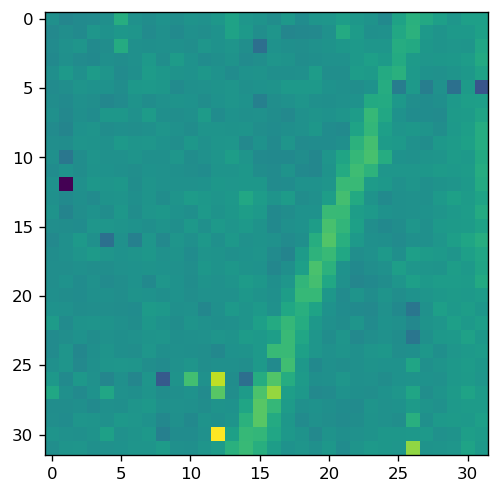

In [60]:
plt.imshow(ds_l1.head(time=10_000_000)['median_subtracted'][3_354_000])

In [10]:
model, bundle = load_classifier(MODEL_PATH)
model.eval()
print(f"Model: {bundle.model_name} v{bundle.model_version}")
print(f"Input spec: {bundle.input_spec}")
print(f"Checksum: {bundle.checksum[:24]}…")
print()

params = CloudInferParams(cadence_s=CADENCE_S, threshold=THRESHOLD)
with torch.no_grad():
    ds_l2 = predict_cloud_score(ds_l1, model, params)

scores = ds_l2["cloud_score"].values
labels = ds_l2["cloud_label"].values
print(f"Windows scored : {len(scores)}")
print(f"cloud_score    : min={scores.min():.3f}  mean={scores.mean():.3f}  max={scores.max():.3f}")
print(f"cloudy windows : {labels.sum()} / {len(labels)} ({labels.mean():.1%})")

Model: cloud_detector v1.0
Input spec: {'cadence_s': 60.0, 'features': ['raw-derivative-fft.-60', 'raw-fft'], 'input_shape': [2, 32, 32]}
Checksum: sha256:abbc3d38052a6c2c4…

Windows scored : 228
cloud_score    : min=0.287  mean=0.881  max=0.917
cloudy windows : 227 / 228 (99.6%)


## §4 Cloud Score Timeline

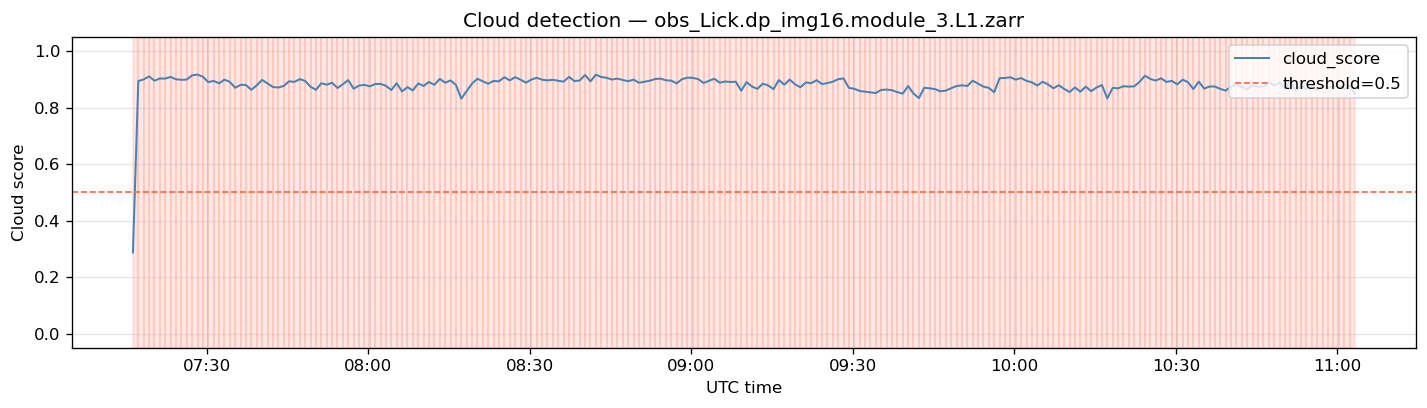

Fraction of night classified as cloudy: 99.6%


In [11]:
t_l2_ns = ds_l2["unix_t_ns"].values
t_l2_dt = [datetime.fromtimestamp(t / 1e9, tz=timezone.utc) for t in t_l2_ns]

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(t_l2_dt, scores, color='steelblue', linewidth=1.2, zorder=2, label='cloud_score')
ax.axhline(THRESHOLD, color='tomato', linestyle='--', linewidth=1, label=f'threshold={THRESHOLD}')

# Shade cloudy windows
cloudy_mask = labels.astype(bool)
for i, (t, is_cloudy) in enumerate(zip(t_l2_dt, cloudy_mask)):
    if is_cloudy:
        ax.axvspan(t_l2_dt[max(0, i-1)], t, alpha=0.15, color='tomato', zorder=1)

ax.set_ylim(-0.05, 1.05)
ax.set_ylabel('Cloud score')
ax.set_xlabel('UTC time')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.set_title(f'Cloud detection — {L1_STORE.name}')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f"Fraction of night classified as cloudy: {labels.mean():.1%}")

## §5 Feature Visualization (4-panel)

For each flagged window, show the four feature maps used by the model.

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


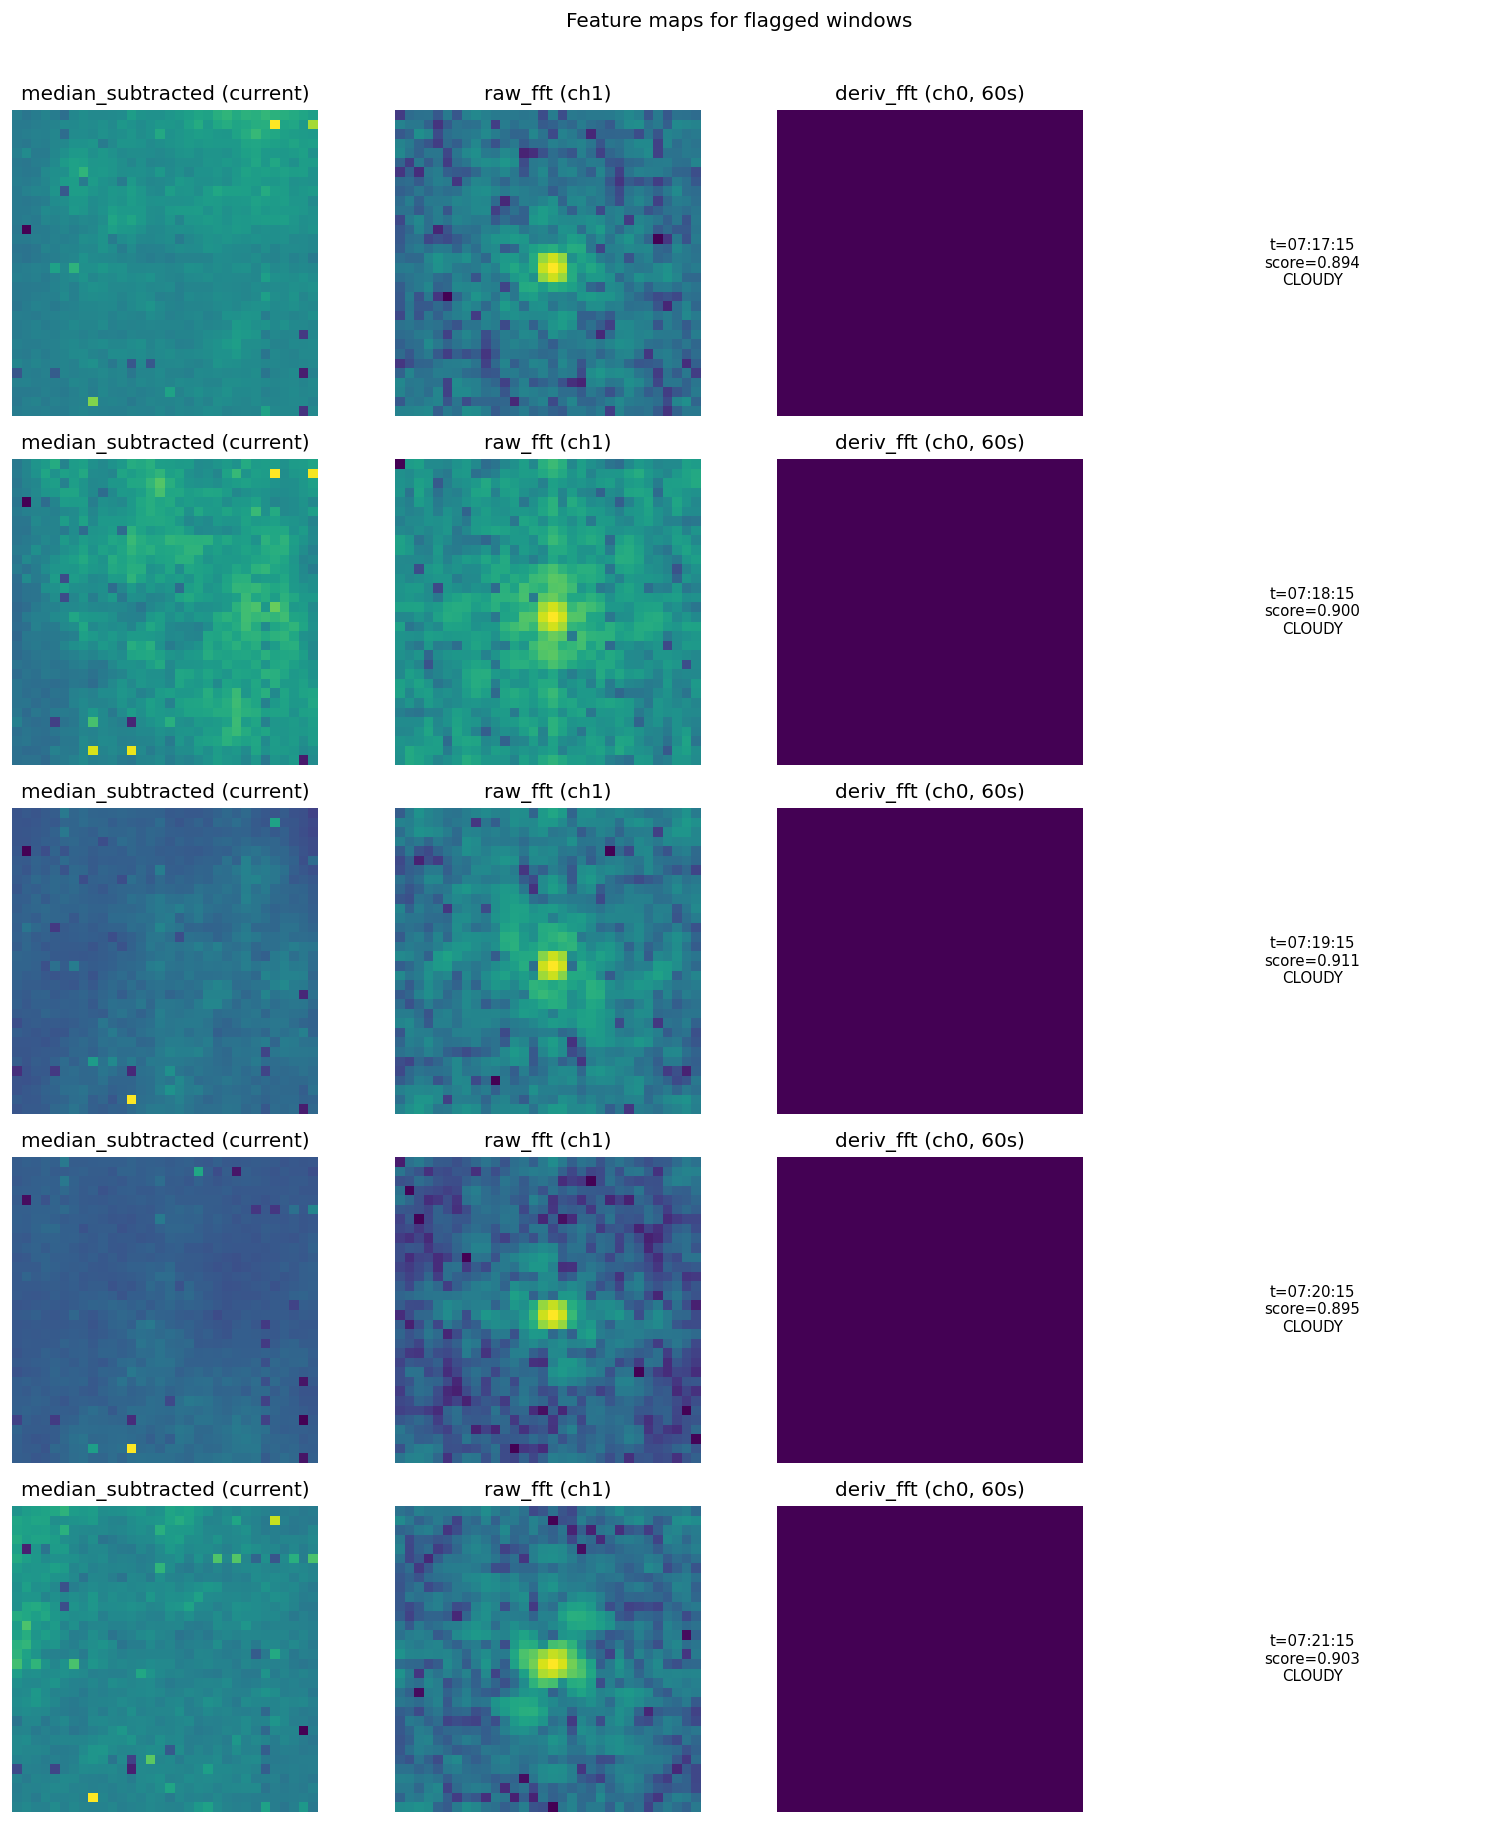

In [16]:
%load_ext autoreload
%autoreload 2
from panoseti_analysis.algorithms.cloud_detector import extract_cloud_features

def _plot_window(ds_l1_in, t_center_ns, ax_row, title=""):
    """Plot 4-panel feature display for a single 60-second window."""
    # Extract features for this specific window
    p = CloudInferParams(cadence_s=CADENCE_S, threshold=THRESHOLD)
    t_ns = ds_l1_in["unix_t_ns"].values
    mask = (t_ns >= t_center_ns - 60_000_000_000) & (t_ns <= t_center_ns)
    if mask.sum() < 10:
        return
    ds_win = ds_l1_in.isel(time=mask)
    X, _ = extract_cloud_features(ds_win, p)
    if len(X) == 0:
        return
    # Use first sample in the window
    deriv_fft = X[0, 0]  # channel 0
    raw_fft   = X[0, 1]  # channel 1
    raw_img   = ds_win["median_subtracted"].values[-1]

    kw = dict(cmap='viridis', interpolation='nearest')
    ax_row[0].imshow(raw_img, **kw)
    ax_row[0].set_title('median_subtracted (current)')
    ax_row[1].imshow(raw_fft, **kw)
    ax_row[1].set_title('raw_fft (ch1)')
    ax_row[2].imshow(deriv_fft, **kw)
    ax_row[2].set_title('deriv_fft (ch0, 60s)')
    ax_row[3].text(0.5, 0.5, title, ha='center', va='center',
                   fontsize=9, transform=ax_row[3].transAxes, wrap=True)
    ax_row[3].axis('off')
    for ax in ax_row[:3]:
        ax.axis('off')

# Show up to 4 flagged windows
flagged_idx = np.where(cloudy_mask)[0][:5]
if len(flagged_idx) == 0:
    print("No cloudy windows detected — showing first 4 windows instead.")
    flagged_idx = np.arange(min(4, len(t_l2_ns)))

fig, axes = plt.subplots(len(flagged_idx), 4, figsize=(13, 3 * len(flagged_idx)))
if len(flagged_idx) == 1:
    axes = [axes]

for row_ax, idx in zip(axes, flagged_idx):
    t_c = int(t_l2_ns[idx])
    t_label = datetime.fromtimestamp(t_c / 1e9, tz=timezone.utc).strftime('%H:%M:%S')
    score = float(scores[idx])
    title = f"t={t_label}\nscore={score:.3f}\n{'CLOUDY' if labels[idx] else 'CLEAR'}"
    _plot_window(ds_l1, t_c, row_ax, title)

plt.suptitle('Feature maps for flagged windows', y=1.01)
plt.tight_layout()
plt.show()

## §6 Score Distribution

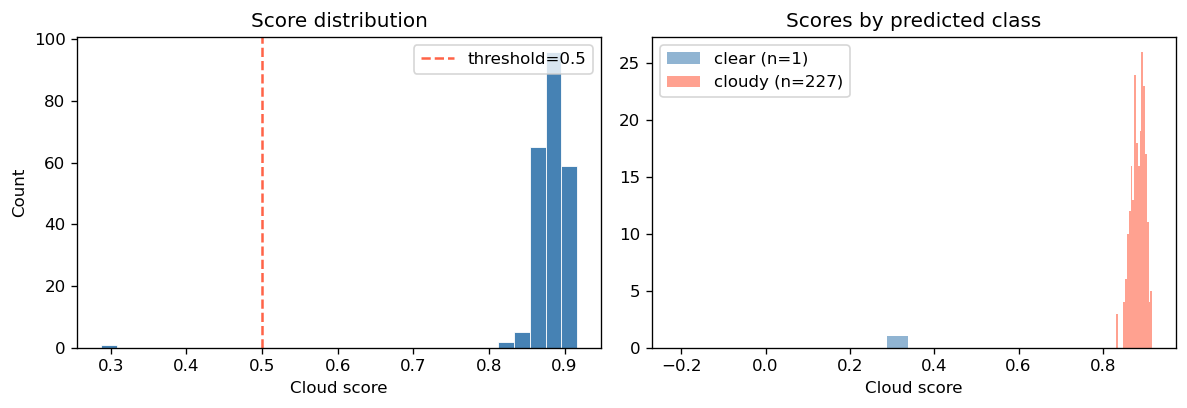

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

ax = axes[0]
ax.hist(scores, bins=30, color='steelblue', edgecolor='white', linewidth=0.5)
ax.axvline(THRESHOLD, color='tomato', linestyle='--', label=f'threshold={THRESHOLD}')
ax.set_xlabel('Cloud score')
ax.set_ylabel('Count')
ax.set_title('Score distribution')
ax.legend()

ax = axes[1]
clear_scores = scores[labels == 0]
cloudy_scores = scores[labels == 1]
ax.hist(clear_scores, bins=20, alpha=0.6, color='steelblue', label=f'clear (n={len(clear_scores)})')
ax.hist(cloudy_scores, bins=20, alpha=0.6, color='tomato', label=f'cloudy (n={len(cloudy_scores)})')
ax.set_xlabel('Cloud score')
ax.set_title('Scores by predicted class')
ax.legend()

plt.tight_layout()
plt.show()

## §7 Summary

In [14]:
duration_min = (t_ns[-1] - t_ns[0]) / 1e9 / 60
print(f"Run summary")
print(f"  Store       : {L1_STORE.name}")
print(f"  Duration    : {duration_min:.1f} min ({len(t_ns):,} frames)")
print(f"  Windows     : {len(scores)} × {CADENCE_S:.0f}s")
print(f"  Cloudy      : {labels.sum()} windows ({labels.mean():.1%})")
print(f"  Score range : {scores.min():.3f} – {scores.max():.3f}")
print(f"  Model       : {bundle.model_name} v{bundle.model_version}")

Run summary
  Store       : obs_Lick.dp_img16.module_3.L1.zarr
  Duration    : 227.1 min (13,625,494 frames)
  Windows     : 228 × 60s
  Cloudy      : 227 windows (99.6%)
  Score range : 0.287 – 0.917
  Model       : cloud_detector v1.0
